In [18]:
# Process and plot lacto supernatant inhibition on enterobacteria

In [1]:
getwd()
#setwd("/home/strawperry/Documentos/lactos-joao/lacto-supernatant-inhibition/")
#getwd()

[1] "/home/strawperry/Documentos/lactos-joao"

In [2]:
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)

read_supernat_long <- function(file_path) {
  raw <- read.delim(
    file_path,
    sep = "\t",
    dec = ",",
    check.names = FALSE,
    stringsAsFactors = FALSE,
    fill = TRUE,
    comment.char = ""
  )

  nm <- names(raw)
  keep <- !(is.na(nm) | nm == "")
  raw <- raw[, keep, drop = FALSE]
  nm <- trimws(nm[keep])
  names(raw) <- nm

  names(raw)[1:2] <- c("reading", "time_s")
  raw <- raw %>% select(time_s, starts_with("Un"))

  file_name <- basename(file_path)
  entero_id <- as.integer(str_match(file_name, "^(\\d+)_\\d+_\\d+_\\d+_\\d+")[, 2])
  lacto_id  <- as.integer(str_match(file_name, "^\\d+_(\\d+)_\\d+_\\d+_\\d+")[, 2])

  raw %>%
    mutate(time_h = time_s / 3600) %>%
    pivot_longer(
      cols = starts_with("Un"),
      names_to = "well_raw",
      values_to = "OD600"
    ) %>%
    mutate(
      well = str_extract(well_raw, "(?<=\\()[A-H]\\d{2}(?=\\))"),
      row = substr(well, 1, 1),
      column = as.integer(substr(well, 2, 3)),
      Entero_ID = entero_id,
      Lacto_ID = lacto_id
    ) %>%
    select(Entero_ID, Lacto_ID, time_s, time_h, well, row, column, OD600)
}

#long_df <- read_supernat_long("supernatant_inhibition/339_347_14_30_060626.tsv")
long_df <- read_supernat_long("supernatant_inhibition/339_347_1_20_140626.tsv")

head(long_df)


Adjuntando el paquete: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Entero_ID,Lacto_ID,time_s,time_h,well,row,column,OD600
<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>
339,347,0,0,A01,A,1,0.092
339,347,0,0,A02,A,2,0.097
339,347,0,0,A03,A,3,0.131
339,347,0,0,A04,A,4,0.109
339,347,0,0,A05,A,5,0.107
339,347,0,0,A06,A,6,0.110


In [3]:
# Add plate conditions
# - MilliQ water on borders: rows A and H, columns 1 and 12
# - Lacto 1: rows B, C, D
# - Lacto 20: rows E, F, G
# - Entero 339: columns 2, 3, 4, 5, 6
# - Entero 347: columns 7, 8, 9, 10, 11
# - Neg control: wells D06, E06, D11, E11  (renamed to C_neg)
# - Pos control: wells B06, C06 (lacto 1 x entero 339), F06, G06 (lacto 20 x entero 339), B11, C11 (lacto 1 x entero 347), F11, G11 (lacto 20 x entero 347)  (renamed to C_pos)

plates_long2 <- long_df %>%
  mutate(
    condition = case_when(
      (row == "D" & column == 6L) |
      (row == "E" & column == 6L) |
      (row == "D" & column == 11L) |
      (row == "E" & column == 11L) ~ "C_neg",
      row %in% c("A", "H") | column %in% c(1L, 12L) ~ "MilliQ water",
      row %in% c("B", "C", "D") & column %in% 2:6 ~ "Lacto 1 x Entero 339",
      row %in% c("B", "C", "D") & column %in% 7:11 ~ "Lacto 1 x Entero 347",
      row %in% c("E", "F", "G") & column %in% 2:6 ~ "Lacto 20 x Entero 339",
      row %in% c("E", "F", "G") & column %in% 7:11 ~ "Lacto 20 x Entero 347",
      TRUE ~ "Unassigned"
    ),
    plate_row = case_when(
      row %in% c("A", "H") ~ "Border",
      row %in% c("B", "C", "D") ~ "Lacto 1",
      row %in% c("E", "F", "G") ~ "Lacto 20",
      TRUE ~ NA_character_
    ),
    plate_col = case_when(
      column %in% c(1L, 12L) ~ "Border",
      column %in% 2:6 ~ "Entero 339",
      column %in% 7:11 ~ "Entero 347",
      TRUE ~ NA_character_
    ),
    Lacto_ID = case_when(
      condition %in% c("MilliQ water", "C_neg") ~ NA_integer_,
      row %in% c("B", "C", "D") ~ 1L,
      row %in% c("E", "F", "G") ~ 20L,
      TRUE ~ NA_integer_
    ),
    Entero_ID = case_when(
      condition %in% c("MilliQ water", "C_neg") ~ NA_integer_,
      column %in% 2:6 ~ 339L,
      column %in% 7:11 ~ 347L,
      TRUE ~ NA_integer_
    ),
    Strain = case_when(
      !is.na(Entero_ID) & !is.na(Lacto_ID) ~ paste0("E", Entero_ID, "_L", Lacto_ID),
      condition %in% c("MilliQ water", "C_neg") ~ condition,
      TRUE ~ NA_character_
    ),
    well = sprintf("%s%02d", row, column)
  ) %>%
  select(Entero_ID, Lacto_ID, Strain, plate_row, plate_col, condition, time_s, time_h, well, row, column, OD600)

head(plates_long2)

Entero_ID,Lacto_ID,Strain,plate_row,plate_col,condition,time_s,time_h,well,row,column,OD600
<int>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>,<dbl>
NA,NA,MilliQ water,Border,Border,MilliQ water,0,0,A01,A,1,0.092
NA,NA,MilliQ water,Border,Entero 339,MilliQ water,0,0,A02,A,2,0.097
NA,NA,MilliQ water,Border,Entero 339,MilliQ water,0,0,A03,A,3,0.131
NA,NA,MilliQ water,Border,Entero 339,MilliQ water,0,0,A04,A,4,0.109
NA,NA,MilliQ water,Border,Entero 339,MilliQ water,0,0,A05,A,5,0.107
NA,NA,MilliQ water,Border,Entero 339,MilliQ water,0,0,A06,A,6,0.110


In [16]:
# Mark the pair-specific positive controls so they do not get mixed into the 1/16 dilution wells
plates_long2 <- plates_long2 %>%
  mutate(
    is_pos_control = case_when(
      Entero_ID == 339L & Lacto_ID == 1L & well %in% c("B06", "C06") ~ TRUE,
      Entero_ID == 339L & Lacto_ID == 20L & well %in% c("F06", "G06") ~ TRUE,
      Entero_ID == 347L & Lacto_ID == 1L & well %in% c("B11", "C11") ~ TRUE,
      Entero_ID == 347L & Lacto_ID == 20L & well %in% c("F11", "G11") ~ TRUE,
      TRUE ~ FALSE
    ),
    condition = case_when(
      is_pos_control ~ "C_pos",
      TRUE ~ condition
    )
  )

plates_long2 %>%
  filter(is_pos_control) %>%
  distinct(Entero_ID, Lacto_ID, well, condition)

Entero_ID,Lacto_ID,well,condition
<int>,<int>,<chr>,<chr>
339,1,B06,C_pos
347,1,B11,C_pos
339,1,C06,C_pos
347,1,C11,C_pos
339,20,F06,C_pos
347,20,F11,C_pos
339,20,G06,C_pos
347,20,G11,C_pos


In [17]:
# Make a summarized table to plot from plates_long2
plates_long3 <- plates_long2 %>%
  select(Entero_ID, Lacto_ID, well, condition, time_h, OD600) %>%
  mutate(
    column = as.integer(substr(well, 2, 3)),
    dilution = case_when(
      condition == "C_neg" ~ "C_neg",
      condition == "C_pos" ~ "C_pos",
      column %in% c(2L, 7L) ~ "1/2",
      column %in% c(3L, 8L) ~ "1/4",
      column %in% c(4L, 9L) ~ "1/8",
      column %in% c(5L, 10L) ~ "1/16",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(
    !is.na(Entero_ID),
    !is.na(Lacto_ID),
    !is.na(well),
    !is.na(condition),
    !is.na(time_h),
    !is.na(OD600),
    !is.na(dilution)
  ) %>%
  arrange(Entero_ID, Lacto_ID, well, condition, time_h)

head(plates_long3)

Entero_ID,Lacto_ID,well,condition,time_h,OD600,column,dilution
<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>
339,1,B02,Lacto 1 x Entero 339,0.0000000,0.166,2,1/2
339,1,B02,Lacto 1 x Entero 339,0.9999778,0.164,2,1/2
339,1,B02,Lacto 1 x Entero 339,1.9999972,0.166,2,1/2
339,1,B02,Lacto 1 x Entero 339,3.0000222,0.168,2,1/2
339,1,B02,Lacto 1 x Entero 339,4.0000389,0.168,2,1/2
339,1,B02,Lacto 1 x Entero 339,5.0000556,0.169,2,1/2


In [18]:
# COLOR PALETTE FOR DILUTIONS AND CONTROLS
# Define a named color map for reuse in all plots
color_map <- c(
  "1" = "#1B9E77",
  "1/2" = "#1B9E77",
  "1/4" = "#D95F02",
  "1/8" = "#7570B3",
  "1/16" = "#E7298A",
  "C_pos" = "#000000",
  "C_neg" = "#7a7a7a"
)


`geom_smooth()` using formula = 'y ~ x'


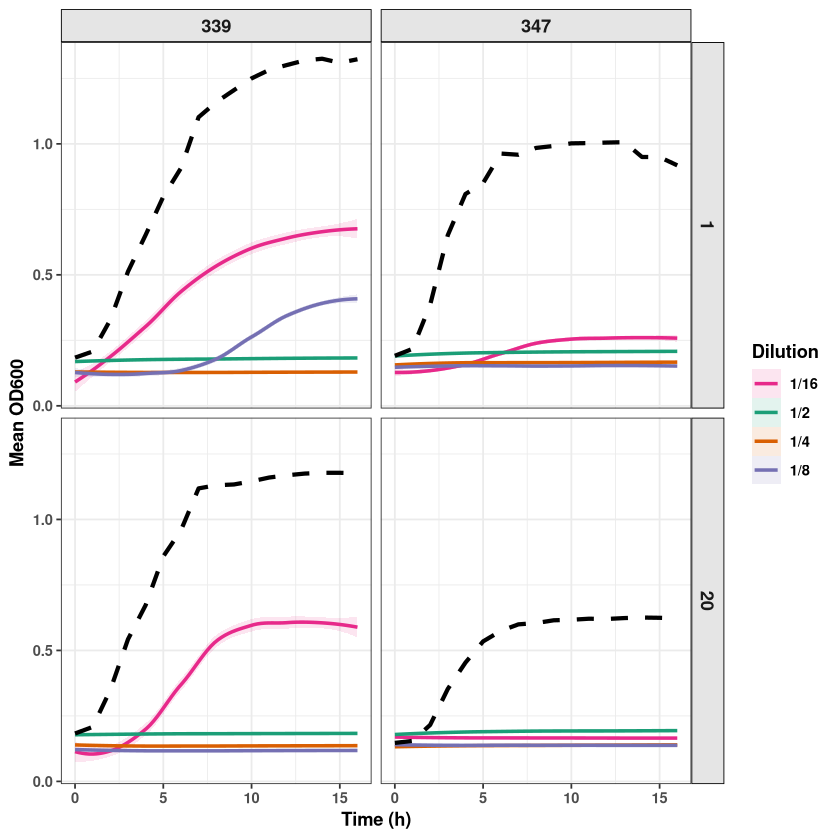

In [19]:
# Ensure proper control labeling
plates_long4 <- plates_long3 %>%
  mutate(
    control_type = case_when(
      condition == "C_neg" ~ "C_neg",
      condition == "C_pos" ~ "C_pos",
      TRUE ~ NA_character_
    ),

    dilution_group = case_when(
      condition %in% c("C_neg") ~ NA_character_,
      condition == "C_pos" ~ NA_character_,
      TRUE ~ dilution
    )
  )

# Summary for everything
summary_df <- plates_long4 %>%
  group_by(Entero_ID, Lacto_ID, dilution_group, control_type, time_h) %>%
  summarise(
    mean_OD600 = mean(OD600, na.rm = TRUE),
    sd_OD600 = sd(OD600, na.rm = TRUE),
    n = dplyr::n(),
    se_OD600 = sd_OD600 / sqrt(n),
    .groups = "drop"
  )

# Clean plot with BLACK control lines per facet
ggplot(summary_df, aes(x = time_h, y = mean_OD600)) +

  # =========================
  # 1. Dilutions (colored + smooth)
  # =========================
  geom_smooth(
    data = subset(summary_df, !is.na(dilution_group)),
    aes(color = dilution_group, fill = dilution_group, group = dilution_group),
    method = "loess",
    se = TRUE,
    linewidth = 1,
    alpha = 0.12
  ) +

  # =========================
  # 2. Negative + Positive controls (BLACK lines, DASHED)
  # =========================
  geom_line(
    data = subset(summary_df, !is.na(control_type)),
    aes(group = control_type),
    color = "black",
    linewidth = 1.2,
    linetype = "dashed"
  ) +

  facet_grid(Lacto_ID ~ Entero_ID) +

  scale_color_manual(values = color_map[c("1", "1/2", "1/4", "1/8", "1/16")]) +
  scale_fill_manual(values = color_map[c("1", "1/2", "1/4", "1/8", "1/16")]) +

  labs(
    x = "Time (h)",
    y = "Mean OD600",
    color = "Dilution",
    fill = "Dilution"
  ) +

  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey90", color = "black"),
    strip.text = element_text(face = "bold", size = 11),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    legend.title = element_text(face = "bold"),
    legend.text = element_text(face = "bold")
  )

Entero_ID,Lacto_ID,series,well,growth_rate
<int>,<int>,<chr>,<chr>,<dbl>
339,1,1/16,B05,0.333527989
339,1,1/16,C05,0.435561656
339,1,1/16,D05,0.051607602
339,1,1/2,B02,0.005655118
339,1,1/2,C02,0.010531004
339,1,1/2,D02,0.015765596


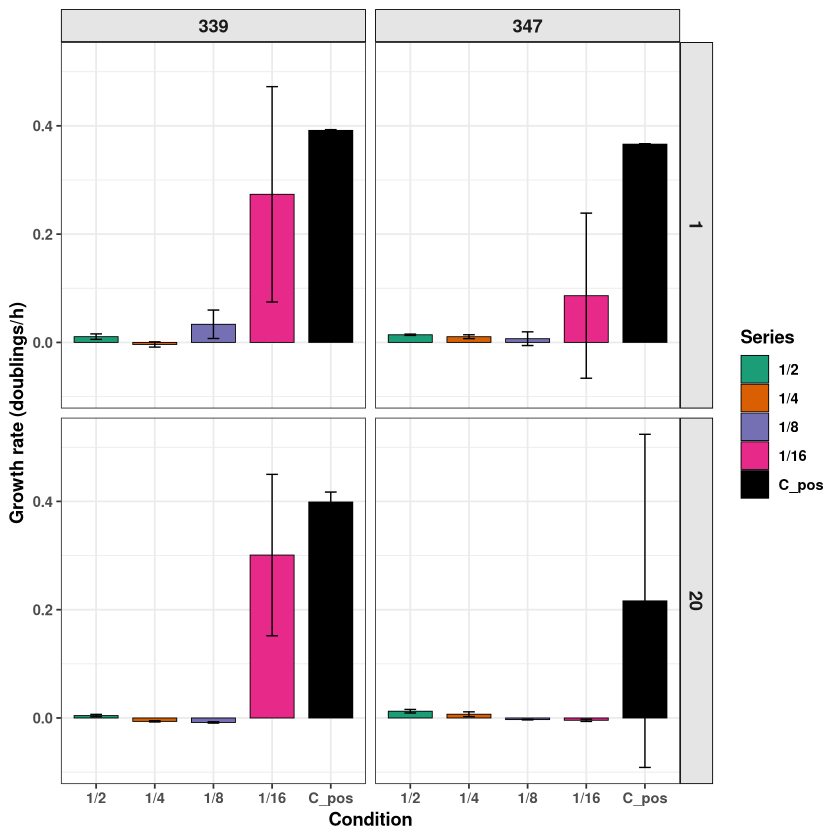

In [20]:
growth_rate_df <- plates_long4 %>%
  mutate(
    series = case_when(
      dilution %in% c("1/2","1/4","1/8","1/16") ~ dilution,
      condition == "C_neg" ~ "C_neg",
      condition == "C_pos" ~ "C_pos",
      TRUE ~ NA_character_
    )
  ) %>%
  group_by(Entero_ID, Lacto_ID, series, well) %>%
  group_modify(~ tibble(
    growth_rate = estimate_growth_rate(.x)
  )) %>%
  ungroup()

head(growth_rate_df)


rate_summary <- growth_rate_df %>%
  group_by(Entero_ID, Lacto_ID, series) %>%
  summarise(
    mean_rate = mean(growth_rate, na.rm = TRUE),
    sd_rate = sd(growth_rate, na.rm = TRUE),
    n = sum(!is.na(growth_rate)),
    .groups = "drop"
  ) %>%
  ungroup()

# Remove C_neg entries (no meaningful growth rate) and order series so C_pos plots on the right
rate_summary <- rate_summary %>%
  filter(series != "C_neg")

all_series <- c("1/2", "1/4", "1/8", "1/16", "C_pos")

rate_summary <- rate_summary %>%
  tidyr::complete(Entero_ID, Lacto_ID, series = all_series, fill = list(mean_rate = NA_real_, sd_rate = NA_real_, n = 0)) %>%
  mutate(
    series = factor(series, levels = all_series),
    mean_rate_plot = ifelse(is.na(mean_rate), 0, mean_rate)
  )

ggplot(rate_summary, aes(x = series, y = mean_rate_plot)) +

  geom_col(aes(fill = series),
           color = "black",
           linewidth = 0.25,
           width = 0.75) +

  geom_errorbar(
    aes(ymin = ifelse(is.na(sd_rate), NA_real_, mean_rate_plot - sd_rate),
        ymax = ifelse(is.na(sd_rate), NA_real_, mean_rate_plot + sd_rate)),
    width = 0.2,
    linewidth = 0.4,
    na.rm = TRUE
  ) +

  facet_grid(Lacto_ID ~ Entero_ID) +

  scale_fill_manual(values = color_map[c("1/2", "1/4", "1/8", "1/16", "C_pos")]) +

  labs(
    x = "Condition",
    y = "Growth rate (doublings/h)",
    fill = "Series"
  ) + 

  theme_bw() +
  
  theme(
    strip.background = element_rect(fill = "grey90", color = "black"),
    strip.text = element_text(face = "bold", size = 11),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(face = "bold"),
    legend.title = element_text(face = "bold"),
    legend.text = element_text(face = "bold")
  )

In [29]:
#install.packages("rstatix")

In [21]:
# Compute non-parametric stats per Entero x Lacto pair
library(rstatix)

# Use per-well growth rates (not group means) and exclude C_neg
gr_sub <- growth_rate_df %>%
  filter(series != "C_neg") %>%
  mutate(series = factor(series))

# Quick counts to detect tiny groups (helps interpret warnings/errors)
counts_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID, series) %>%
  summarise(n = sum(!is.na(growth_rate)), .groups = "drop")

counts_df

# 1) Kruskal-Wallis test across series per Entero x Lacto pair
# This is robust when assumptions for ANOVA are not met or sample sizes are small
kruskal_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID) %>%
  kruskal_test(growth_rate ~ series)

kruskal_df

# 2) Post-hoc Dunn test (correct approach after Kruskal-Wallis)
# Compare C_pos to each dilution
dunn_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID) %>%
  dunn_test(growth_rate ~ series, p.adjust.method = "fdr") %>%
  filter(group1 == "C_pos" | group2 == "C_pos") %>%
  arrange(Entero_ID, Lacto_ID)

dunn_df


Entero_ID,Lacto_ID,series,n
<int>,<int>,<fct>,<int>
339,1,1/16,3
339,1,1/2,3
339,1,1/4,3
339,1,1/8,3
339,1,C_pos,2
339,20,1/16,3
339,20,1/2,3
339,20,1/4,3
339,20,1/8,3


,Entero_ID,Lacto_ID,.y.,n,statistic,df,p,method
,<int>,<int>,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>
1,339,1,growth_rate,14,11.752381,4,0.0193,Kruskal-Wallis
2,339,20,growth_rate,14,11.828571,4,0.0187,Kruskal-Wallis
3,347,1,growth_rate,14,5.733333,4,0.2200,Kruskal-Wallis
4,347,20,growth_rate,14,10.152381,4,0.0379,Kruskal-Wallis


Entero_ID,Lacto_ID,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
339,1,growth_rate,1/16,C_pos,3,2,0.3055050,0.759981527,0.75998153,ns
339,1,growth_rate,1/2,C_pos,3,2,1.9639610,0.049534613,0.12741820,ns
339,1,growth_rate,1/4,C_pos,3,2,2.7495454,0.005967799,0.03142591,*
339,1,growth_rate,1/8,C_pos,3,2,1.0910895,0.275233524,0.42197275,ns
339,20,growth_rate,1/16,C_pos,3,2,0.2182179,0.827259347,0.82725935,ns
339,20,growth_rate,1/2,C_pos,3,2,1.1783766,0.238646499,0.39774417,ns
339,20,growth_rate,1/4,C_pos,3,2,2.0512482,0.040242785,0.10105995,ns
339,20,growth_rate,1/8,C_pos,3,2,2.6622583,0.007761830,0.03880915,*
347,1,growth_rate,1/16,C_pos,3,2,2.0512482,0.040242785,0.20121393,ns


In [22]:
# Parametric version: ANOVA + Tukey HSD post-hoc test
# (as comparison to the non-parametric Kruskal-Wallis + Dunn approach above)

# 1) One-way ANOVA across series per Entero x Lacto pair
anova_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID) %>%
  anova_test(growth_rate ~ series)

anova_df

# 2) Post-hoc Tukey HSD test (pairwise comparisons; includes all pairs)
tukey_df <- gr_sub %>%
  group_by(Entero_ID, Lacto_ID) %>%
  tukey_hsd(growth_rate ~ series) %>%
  filter(group1 == "C_pos" | group2 == "C_pos") %>%
  arrange(Entero_ID, Lacto_ID)

tukey_df

,Entero_ID,Lacto_ID,Effect,DFn,DFd,F,p,p<.05,ges
,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,339,1,series,4,9,9.003,0.00300,*,0.800
2,339,20,series,4,9,19.642,0.00018,*,0.897
3,347,1,series,4,9,9.960,0.00200,*,0.816
4,347,20,series,4,9,1.866,0.20100,,0.453


Entero_ID,Lacto_ID,term,group1,group2,null.value,estimate,conf.low,conf.high,p.adj,p.adj.signif
<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
339,1,series,1/16,C_pos,0,0.11803490,-0.17242311,0.4084929,0.661000,ns
339,1,series,1/2,C_pos,0,0.38095008,0.09049207,0.6714081,0.011100,*
339,1,series,1/4,C_pos,0,0.39539880,0.10494079,0.6858568,0.008850,**
339,1,series,1/8,C_pos,0,0.35811988,0.06766187,0.6485779,0.016100,*
339,20,series,1/16,C_pos,0,0.09798056,-0.11856725,0.3145284,0.575000,ns
339,20,series,1/2,C_pos,0,0.39445228,0.17790447,0.6110001,0.001220,**
339,20,series,1/4,C_pos,0,0.40518223,0.18863441,0.6217300,0.001010,**
339,20,series,1/8,C_pos,0,0.40715006,0.19060224,0.6236979,0.000971,***
347,1,series,1/16,C_pos,0,0.27988055,0.05842867,0.5013324,0.013900,*
